# Learning an embedding function with a `Siamese' Network

Learning objectives: 

* to understand the point of learning an embedding function for one-shot learning

* to see how to construct two (or more) networks with shared weights in Keras

* to train an embedding function using a Siamese network with contrastive divergence, and understand how to assess its performance

In [91]:
# as usual we import numpy and matplotlib in the conventional way

import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

In [92]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [93]:
import torchvision
import torchvision.datasets as datasets
from torchvision import transforms

In [94]:
# These are arrays of small digits - but for this practical we will normalise them (as is good practice)
# to have zero mean and sensible sizes (in the region of 1)
transform_list = transforms.Compose([ transforms.ToTensor(), transforms.Normalize(mean=[0.0], std=[1.0,]) ] )

In [95]:
# Load MNIST train dataset
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform_list)

In [96]:
# MNIST train dataset summary
mnist_trainset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.0], std=[1.0])
           )

In [97]:
# Load MNIST test dataset
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform_list)

In [98]:
# MNIST testdataset summary
mnist_testset

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.0], std=[1.0])
           )

In [99]:
# To access data
mnist_trainset.data.shape

torch.Size([60000, 28, 28])

In [100]:
# To access labels
mnist_trainset.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

In [101]:
# let's plot the average value of each pixel in the images. Note that the original data type is uint8.
# So we convert the tensor type to double before computing the mean.

mean_image = torch.mean(mnist_trainset.data.type(torch.DoubleTensor), axis=0)
mean_image.shape

torch.Size([28, 28])

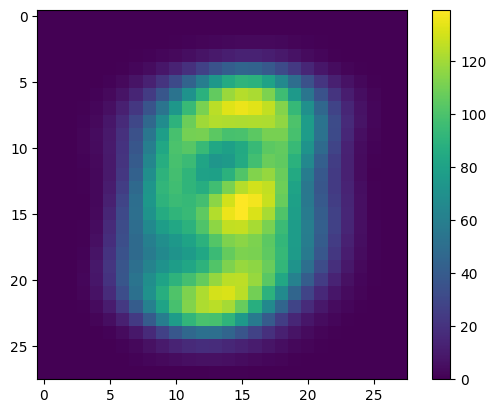

In [102]:
# now plot it - some pixels are going to be more important than others
# in the MNIST dataset, the digits have been centred. The maximum value
# is 255, and the 
plt.imshow( mean_image)
plt.colorbar()


In [103]:
# if you don't know, find out what reshape(-1) does with a tensor
mnist_trainset.data[0].reshape(-1)

tensor([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
         18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 1

In [104]:
y_train = mnist_trainset.targets
y_test = mnist_testset.targets

In [105]:
# Build centred image tensors (float). Prefer not to reuse the name `x_train` for something else later.
# Uses `mean_image` from the training set for both train and test (standard practice).
x_train = mnist_trainset.data.type(torch.DoubleTensor) - mean_image
x_test = mnist_testset.data.type(torch.DoubleTensor) - mean_image


(array([272.,  58.,  51.,  36.,  39.,  27.,  30.,  36.,  45., 190.]),
 array([  0.        ,  11.38140078,  22.76280156,  34.14420233,
         45.52560311,  56.90700389,  68.28840467,  79.66980545,
         91.05120622, 102.432607  , 113.81400778]),
 <BarContainer object of 10 artists>)

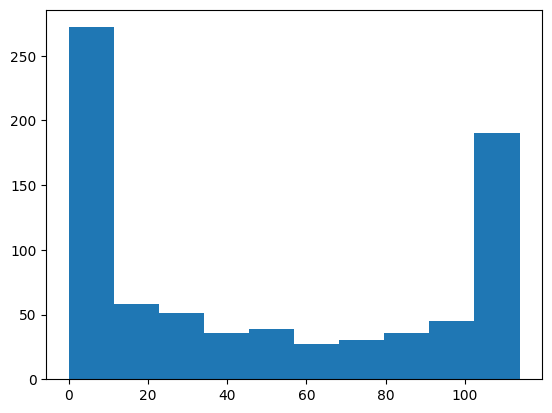

In [106]:
# as always, look at the values in the data. 
# what are the standard deviations of pixels, over the dataset? 

# x_train.reshape((-1,784)) reshapes each image into a 784 element row vector, so we have a 60000x784 
# matrix, with one column corresponding to each pixel

# next, compute the standard deviation of each
pixel_std = torch.std( x_train.reshape((-1,784)), dim=0)

# pyplot expects numpy array so we convert the tensor pixel_std to numpy. 
plt.hist(pixel_std.numpy())

(array([ 2227990.,  4185166.,  5607927., 28283466.,   762712.,   794247.,
         1677842.,  2265744.,   884265.,   350641.]),
 array([-2.11033038, -1.5137185 , -0.91710662, -0.32049474,  0.27611714,
         0.87272902,  1.4693409 ,  2.06595278,  2.66256466,  3.25917654,
         3.85578842]),
 <BarContainer object of 10 artists>)

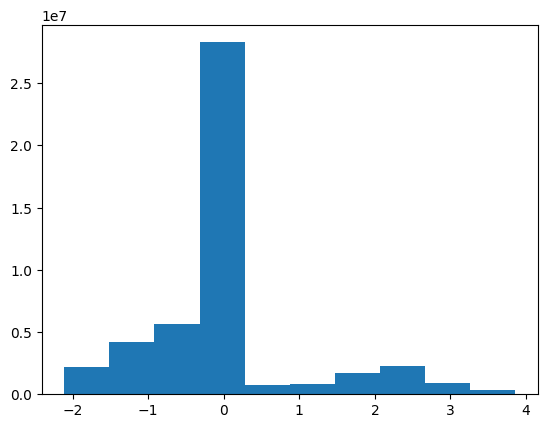

In [107]:
# Normalising the values is quite tricky: we want to get the values to have a standard deviation of roughly
# one - but this may not be possible or reasonable, because some pixels are zero in nearly all the images. 
# We don't want to make these pixel values enormous for the very few images in which they appear

# So a reasonable normalisation which will make all pixel values have small, reasonable values is to 
# divide all pixel values by the standard deviation of _all_ pixel values.

std_train = torch.std( x_train.reshape(-1) )

x_train = x_train / std_train
x_test = x_test / std_train

x_train.reshape(-1).shape
plt.hist( x_train.reshape(-1).numpy())

# Looks ok - all pixel values are between -2 and +4
# this makes learning faster in the initial stages; if the first layer has saturating neurons
# ( such as neurons with activation tanh) then large input values can cause all the neurons to 
# saturate, forcing all gradients small, which slows down learning in the initial stages. 

# Constructing the Training and Test Data for a Siamese Network

One difference between learning an embedding and classification learning is that to learn an embedding, 
we want to train according to the distances betweeen pairs of items. 

Each training example consists of ***two*** digit images, and the label `y` will be 0 if the images are similar (in this case, if they are of the same digit), and 1 if they are different. 

In learning an embedding, we seek to adjust the embedding function to make the embedding vectors of similar pairs be close together, and the embedding vectors of different pairs to be a distance of at least one apart. 

First, we need to construct a training set of pairs of digit-images, together with the appropriate `y` values. 

In [108]:
# Now construct a data set
#
# Random pairs of images have P(same digit) ≈ 1/10 and P(different) ≈ 9/10.
# To get roughly balanced positive (same) vs negative (different) pairs, we always
# keep same-digit pairs, and keep a different-digit pair with probability 1/9
# (because (9/10) * (1/9) = 1/10).

import random

# P(keep | different digits) — balances acceptance rates (see comment above)
ACCEPT_DIFFERENT_PAIR_PROB = 1.0 / 9.0


def construct_pairs_dataset(n_pairs, mnist_images, mnist_labels):
    """Build Siamese pairs: two image tensors and labels y (0 = same digit, 1 = different).

    Returns ([img_batch_a, img_batch_b], y) where each batch has shape (n_pairs, 28, 28, 1).
    """
    n_mnist = mnist_images.shape[0]
    assert mnist_labels.shape[0] == n_mnist

    img_a = torch.zeros((n_pairs, 28, 28, 1))
    img_b = torch.zeros((n_pairs, 28, 28, 1))
    y = torch.zeros((n_pairs, 1))

    for i in range(n_pairs):
        while True:
            idx_a, idx_b = random.sample(range(n_mnist), 2)
            same_digit = mnist_labels[idx_a] == mnist_labels[idx_b]

            if same_digit:
                y[i, 0] = 0
                break
            if random.random() < ACCEPT_DIFFERENT_PAIR_PROB:
                y[i, 0] = 1
                break

        img_a[i, :, :, 0] = mnist_images[idx_a]
        img_b[i, :, :, 0] = mnist_images[idx_b]

    return [img_a, img_b], y


In [109]:
pairs_train, py_train = construct_pairs_dataset( 2000, x_train, y_train)
pairs_test, py_test = construct_pairs_dataset( 2000, x_test, y_test)

In [110]:
print(type(pairs_train))

# Create a tensor of the pairs_train list. 
pairs_train_tensor = torch.stack(pairs_train)
print(pairs_train_tensor.shape)

# Permute the first 2 dimensions of number of 
# samples and the pairs of images and the last 3
# to move the channel to dimension 2
pairs_train_tensor = pairs_train_tensor.permute(1,0,4,2,3)
print(pairs_train_tensor.shape)

<class 'list'>
torch.Size([2, 2000, 28, 28, 1])
torch.Size([2000, 2, 1, 28, 28])


In [111]:
# Create a tensor of the pairs_test and permute dimensions 
# similar to the train data
pairs_test_tensor = torch.stack(pairs_test)
print(pairs_test_tensor.shape)
pairs_test_tensor = pairs_test_tensor.permute(1,0,4,2,3)
print(pairs_test_tensor.shape)

torch.Size([2, 2000, 28, 28, 1])
torch.Size([2000, 2, 1, 28, 28])


In [112]:
#  Now let's just check that our pairs data really is what we think it is

pairs0 = pairs_train[:][0]
pairs1 = pairs_train[:][1]


label 0.0


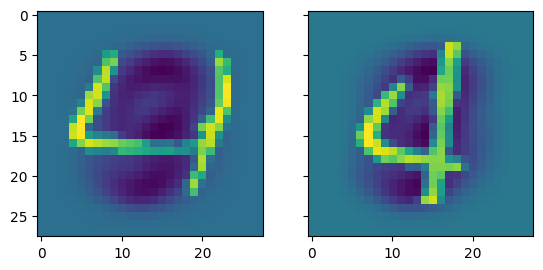

In [113]:
# we define idx to be any valid index for the training data, and then we plot both images, and also print the 
# corresponding `y` value. We can then see if images of the same digit do have y==0, and of different digits
# do have y==1. 

idx = np.random.randint(2000)
fig,ax = plt.subplots(nrows=1, ncols=2, sharex=True, sharey=True)
ax = ax.flatten()
ax[0].imshow( pairs0[idx,:,:,0]) 
ax[1].imshow( pairs1[idx,:,:,0])

# Note that to access the value of the scalar tensor we use .item()
print('label', py_train[idx].item())

# Constructing the Siamese network

We construct the embedding network and the Siamese network separately.  The embedding network is used as a component in the Siamese network. 

But first we need to define functions for Euclidean distances (this will compute the distances between embedding vectors that we wish to minimise), and for the contrastive divergence


In [114]:
# this function computes a new tensor, containing the euclidean distances
# between corresponding rows in the two tensors whose distances we want to compute

def euclidean_distances_of_rows(inputs):
    """
    inputs is a batch of tensors each being a tensor (array) with at least two dimensions;
    this then defines a program to compute the 
    """
    assert inputs.shape[1] == 2, \
        'List/tuple of length 2 needed: argument length is %d ' % len(inputs)
    diff = inputs[:,0,:]-inputs[:,1,:]
    return torch.sqrt( torch.sum( torch.square(diff), dim=1, keepdims=True) )

In [115]:
# this function computes contrastive loss
# it looks deceptively like a Python function, but the inputs will be Tensors
# In this case, the inputs will be a Tensor of true class labels for the current batch, 
# and a Tensor of the computed Euclidean distances for the current batch

# We will use this contrastive loss instead of the log-loss we have generally been using so far. 

def contrastive_loss(y, d):
    # create a tensor of zeros the same size as d to compute the maximum by rows
    zero_tensor = torch.zeros(d.shape)
    
    loss = (( (1-y) * torch.square(d)) + y * torch.square(torch.max(1-d,zero_tensor))).mean()

    return loss

In [116]:
# define the dense embedding model
class embedding_model_1(nn.Module):
    def __init__(self):
        super(embedding_model_1, self).__init__()
        self.model = nn.Sequential( 
                        nn.Flatten(),
                        nn.Linear(784,30),
                        nn.ReLU(),
                        nn.Linear(30,30),
                        nn.Tanh())
    def forward(self, inputs):
        return self.model(inputs)

In [117]:
embedding_model = embedding_model_1()

In [118]:
# define the Siamese Network
class SiameseNetworkModel(nn.Module):
    def __init__(self, embedding_model):
        super(SiameseNetworkModel, self).__init__()
        # embedding model
        self.embedding_model = embedding_model
    
    def forward(self, inputs):
        
        out_a = self.embedding_model( inputs[:,0,:,:])
        out_b = self.embedding_model( inputs[:,1,:,:])

        out_a_b = torch.stack([out_a, out_b]).transpose(0,1)
        s1 = euclidean_distances_of_rows(out_a_b)
        
        return s1

In [119]:
siamese_network_model = SiameseNetworkModel(embedding_model)

Before training the Siamese network, let us look carefully at what is being computed

The digit embeddings are computed by the embedding network

In [120]:
# we can use the embedding model's initialised weights to predict the embedding vectors
# for each digit in the untrained model. 

# look at the shapes of these
# what are they? 

# note that we are detaching the tensors so the gradients are no longer computed
# Conv2d expects NCHW (batch, channels, H, W); pairs_train is stored as NHWC
x0 = pairs_train[0].permute(0, 3, 1, 2)
x1 = pairs_train[1].permute(0, 3, 1, 2)
emb0 = embedding_model(x0).detach()
emb1 = embedding_model(x1).detach()


In [121]:
# we can compute in Python distances between the embedding vectors of each pair of digit-images

# with torch.no_grad():
distances_from_emb01 = np.sqrt( np.sum( np.square( emb0.numpy() - emb1.numpy() ), axis = 1))
distances_from_emb01

array([1.6117724, 1.6770155, 1.7568665, ..., 1.4947209, 1.9627259,
       1.067116 ], shape=(2000,), dtype=float32)

In [122]:
# the output (not the losses) of the Siamese network should be the same numbers - the distances between 
# pairs of embedding vectors

distances = siamese_network_model(pairs_train_tensor).detach()
distances

tensor([[1.6118],
        [1.6770],
        [1.7569],
        ...,
        [1.4947],
        [1.9627],
        [1.0671]])

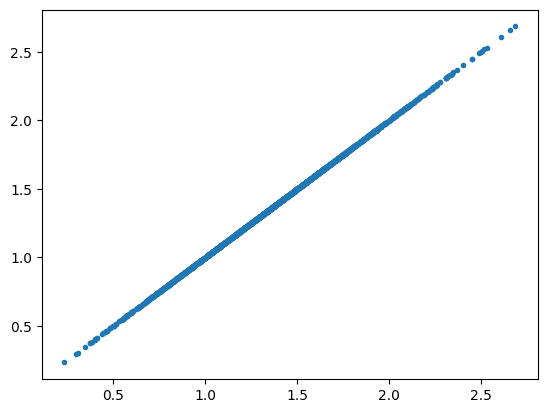

In [123]:
# let's check that the distances computed by the Siamese network, and the distances we computed 
# in Python, are really the same, by plotting them against each other

# note that I reshape the network output to make it a one-dimensional vector

plt.plot( distances.reshape([-1]), distances_from_emb01, '.')

# this graph should be a straight line corresponding to the identity function ! 

In [147]:
# now calculate what the loss should be

# this is a function that computes the contrastive loss in Python (as opposed to in pytorch)
def python_contrastive_loss( y, d):
    result = (( (1-y) * np.square(d)) + y * np.square(np.maximum(1-d,0))) 
    return result.mean()

# Now use this function to compute the mean contrastive loss over the training set, 

In [148]:
pcl = python_contrastive_loss( py_train.numpy(), distances.numpy() )
pcl

np.float32(0.8470166)

In [149]:
# we can evaluate the loss of the untrained Siamese network on the training data:
# the loss should be the same as the one we computed in Python, above.
loss_criterion = contrastive_loss
loss = loss_criterion(py_train, distances)
loss.item()

0.8470165729522705

In [151]:
# training the Siamese network
def train_model(embedding_distance_model, num_epochs=1, trainloader=None, optimizer=None, loss_criterion=True):
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        num_batches = 0
        for inputs, labels in trainloader:
            train_running_accuracy = 0.0
            
            outputs = embedding_distance_model(inputs)
            
            optimizer.zero_grad()
            
            loss = loss_criterion(labels, outputs)

            loss.backward()
            
            optimizer.step()
            
            running_loss += loss.item()
            
            num_batches+=1

        print('epoch %d' % epoch,
              'training loss %.2f' % (running_loss/num_batches))

In [152]:
# create a torch dataset and data loader from the pairs_train and py_train
dataset = torch.utils.data.TensorDataset(pairs_train_tensor, py_train)
trainloader = torch.utils.data.DataLoader(dataset, batch_size=100,shuffle=True)

In [153]:
# define the optimizer
optimizer = optim.RMSprop(siamese_network_model.parameters(), lr=0.001)

In [130]:
# now fit the Siamese model
# I have put episodes = 5, but you may need more episodes to complete the training

train_model(siamese_network_model, num_epochs=5, trainloader=trainloader, 
            optimizer=optimizer, loss_criterion=loss_criterion)


epoch 0 training loss 0.52
epoch 1 training loss 0.19
epoch 2 training loss 0.14
epoch 3 training loss 0.11
epoch 4 training loss 0.09


In [154]:
# Now let's plot the distances between same-digit pairs and different-digit pairs after training, for the 
# training and test sets

preds_after_training = siamese_network_model( pairs_train_tensor ).detach().reshape(-1)
test_preds_after_training = siamese_network_model( pairs_test_tensor ).detach().reshape(-1)

In [155]:
torch.mean( preds_after_training[ py_train[:,0] == 0 ]), torch.mean( preds_after_training[ py_train[:,0] == 1 ])

(tensor(0.3258), tensor(0.8760))

In [156]:
torch.mean( test_preds_after_training[ py_test[:,0] == 0 ]), torch.mean( test_preds_after_training[ py_test[:,0] == 1 ])

(tensor(0.4866), tensor(0.8034))

(array([ 14.,  72., 217., 296., 253., 112.,  40.,  11.,   2.,   2.]),
 array([0.39192104, 0.5209235 , 0.64992589, 0.77892828, 0.90793073,
        1.03693318, 1.16593552, 1.29493797, 1.42394042, 1.55294287,
        1.6819452 ]),
 <BarContainer object of 10 artists>)

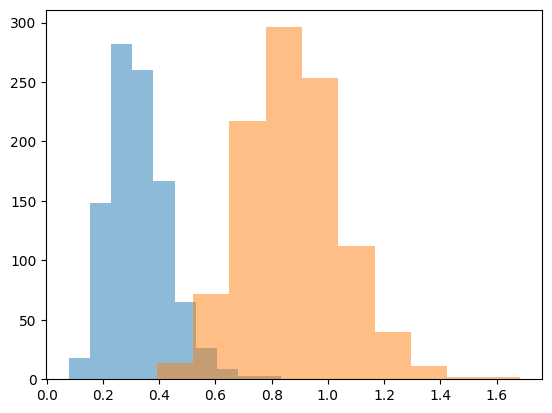

In [134]:
plt.hist( preds_after_training[ py_train[:,0] == 0 ].numpy(), alpha=0.5, label='same')
plt.hist( preds_after_training[ py_train[:,0] == 1 ].numpy(), alpha=0.5, label='different')

# this plot should show the training set has been clearly separated - different 
# digits are further apart than same-digits

(array([ 25.,  86., 167., 259., 244., 139.,  56.,  16.,   2.,   2.]),
 array([0.26673758, 0.40534604, 0.54395449, 0.68256301, 0.82117146,
        0.95977992, 1.09838843, 1.23699689, 1.37560534, 1.5142138 ,
        1.65282226]),
 <BarContainer object of 10 artists>)

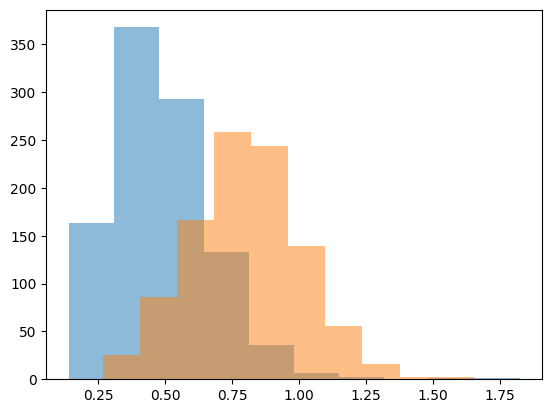

In [157]:
plt.hist( test_preds_after_training[ py_test[:,0] == 0 ].numpy(), alpha=0.5, label='same')
plt.hist( test_preds_after_training[ py_test[:,0] == 1 ].numpy(), alpha=0.5, label='different')

# this plot may show considerable overlap still present in the test set, if there has been 
# overfitting. 

# some embedding networks will be much better than others! 

In [136]:
# we can now try a different embedding model using convolutional and dense layers
class embedding_model_2(nn.Module):
    def __init__(self):
        super(embedding_model_2, self).__init__()
        self.model = nn.Sequential( 
                        nn.Conv2d(in_channels=1, out_channels=20, kernel_size=3),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=20, out_channels=40, kernel_size=3), 
                        nn.ReLU(),
                        nn.MaxPool2d(2, 2),
                        nn.Conv2d(in_channels=40, out_channels=40, kernel_size=3),
                        nn.ReLU(),
                        nn.MaxPool2d(2, 2),
                        nn.Flatten(),
                        nn.Linear(1000, 30),
                        nn.Tanh())
        
    def forward(self, inputs):
        return self.model(inputs)        

In [158]:
embedding_model = embedding_model_2()

In [159]:
embedding_model(pairs_train_tensor[:, 0]).shape

torch.Size([2000, 30])

In [160]:
# initialize a Siamese network with the new embedding model
siamese_network_model_2 = SiameseNetworkModel(embedding_model)

In [161]:
# define the optimizer with the new Siamese network
optimizer_2 = optim.RMSprop(siamese_network_model_2.parameters(), lr=0.001)

In [162]:
# now fit the Siamese model
# I have put episodes = 5, but you may need more episodes to complete the training

train_model(siamese_network_model_2, num_epochs=5, trainloader=trainloader, 
            optimizer=optimizer_2, loss_criterion=loss_criterion)


epoch 0 training loss 0.53
epoch 1 training loss 0.51
epoch 2 training loss 0.41
epoch 3 training loss 0.16
epoch 4 training loss 0.12


In [142]:
# Now let's plot the distances between same-digit pairs and different-digit pairs after training, for the 
# training and test sets

preds_after_training = siamese_network_model_2( pairs_train_tensor ).detach().reshape(-1)
test_preds_after_training = siamese_network_model_2( pairs_test_tensor ).detach().reshape(-1)

In [143]:
torch.mean( preds_after_training[ py_train[:,0] == 0 ]), torch.mean( preds_after_training[ py_train[:,0] == 1 ])

(tensor(0.2800), tensor(0.8779))

In [144]:
torch.mean( test_preds_after_training[ py_test[:,0] == 0 ]), torch.mean( test_preds_after_training[ py_test[:,0] == 1 ])

(tensor(0.3205), tensor(0.8424))

(array([  4.,  34.,  72., 123., 185., 249., 183., 106.,  46.,  17.]),
 array([0.14982118, 0.28718239, 0.42454356, 0.56190479, 0.69926596,
        0.83662713, 0.97398835, 1.11134958, 1.24871075, 1.38607192,
        1.52343309]),
 <BarContainer object of 10 artists>)

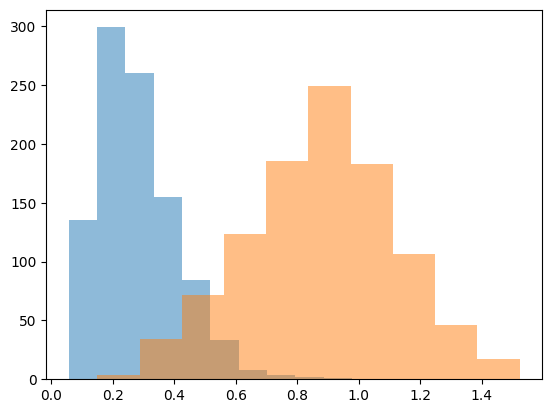

In [145]:
plt.hist( preds_after_training[ py_train[:,0] == 0 ].numpy(), alpha=0.5, label='same')
plt.hist( preds_after_training[ py_train[:,0] == 1 ].numpy(), alpha=0.5, label='different')

# this plot should show the training set has been clearly separated - different 
# digits are further apart than same-digits

(array([ 16.,  73., 102., 150., 210., 193., 150.,  65.,  29.,   8.]),
 array([0.1728054 , 0.31531999, 0.45783457, 0.60034919, 0.74286377,
        0.88537836, 1.02789295, 1.17040753, 1.31292212, 1.45543671,
        1.59795129]),
 <BarContainer object of 10 artists>)

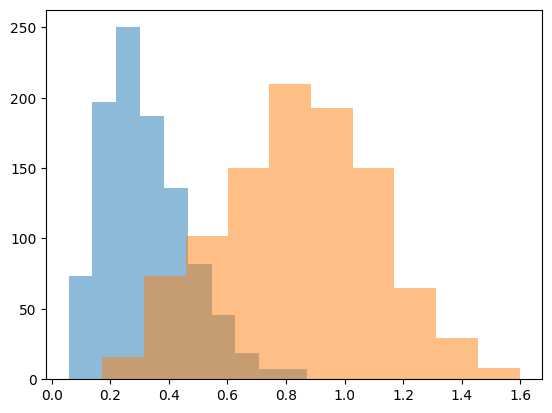

In [146]:
plt.hist( test_preds_after_training[ py_test[:,0] == 0 ].numpy(), alpha=0.5, label='same')
plt.hist( test_preds_after_training[ py_test[:,0] == 1 ].numpy(), alpha=0.5, label='different')

# this plot may show considerable overlap still present in the test set, if there has been 
# overfitting. 

# some embedding networks will be much better than others! 